In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from matplotlib.ticker import PercentFormatter

In [ ]:
# evaluation of all runs (100)
base = Path.cwd() / "model_output" / "MIA"

all_data = []
for i in range(42, 47):
    path = base / f"results_rf_{i}.json"
    if not path.exists():
        print(f"Missing file: {path}")
        continue
    with open(path, "r") as f:
        data = json.load(f)
    for run in data:
        run["_source_file"] = path.name
    all_data.extend(data)

df = pd.DataFrame(all_data)

baseline = df["baseline"]

mia_member_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia"]["member_acc"])
mia_nonmember_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia"]["nonmember_acc"])
mia_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia"]["acc"])

mia_on_SHAP_member_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia_on_SHAP"]["member_acc"])
mia_on_SHAP_nonmember_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia_on_SHAP"]["nonmember_acc"])
mia_on_SHAP_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia_on_SHAP"]["acc"])

mia_with_SHAP_member_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia_with_SHAP"]["member_acc"])
mia_with_SHAP_nonmember_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia_with_SHAP"]["nonmember_acc"])
mia_with_SHAP_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia_with_SHAP"]["acc"])

mia_FI_member_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia_FI"]["member_acc"])
mia_FI_nonmember_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia_FI"]["nonmember_acc"])
mia_FI_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia_FI"]["acc"])

df["mia_on_SHAP_vs_mia_delta"] = mia_on_SHAP_acc - mia_acc
df["mia_on_SHAP_improved"] = df["mia_on_SHAP_vs_mia_delta"] > 0

df["mia_on_SHAP_member_vs_mia_member_delta"] = mia_on_SHAP_member_acc - mia_member_acc
df["mia_on_SHAP_member_improved"] = df["mia_on_SHAP_member_vs_mia_member_delta"] > 0

df["mia_on_SHAP_nonmember_vs_mia_nonmember_delta"] = mia_on_SHAP_nonmember_acc - mia_nonmember_acc
df["mia_on_SHAP_nonmember_improved"] = df["mia_on_SHAP_nonmember_vs_mia_nonmember_delta"] > 0

df["mia_with_SHAP_vs_mia_delta"] = mia_with_SHAP_acc - mia_acc
df["mia_with_SHAP_improved"] = df["mia_with_SHAP_vs_mia_delta"] > 0

df["mia_with_SHAP_member_vs_mia_member_delta"] = mia_with_SHAP_member_acc - mia_member_acc
df["mia_with_SHAP_member_improved"] = df["mia_with_SHAP_member_vs_mia_member_delta"] > 0

df["mia_with_SHAP_nonmember_vs_mia_nonmember_delta"] = mia_with_SHAP_nonmember_acc - mia_nonmember_acc
df["mia_with_SHAP_nonmember_improved"] = df["mia_with_SHAP_nonmember_vs_mia_nonmember_delta"] > 0

df["mia_FI_vs_mia_delta"] = mia_FI_acc - mia_acc
df["mia_FI_improved"] = df["mia_FI_vs_mia_delta"] > 0

df["mia_FI_member_vs_mia_member_delta"] = mia_FI_member_acc - mia_member_acc
df["mia_FI_member_improved"] = df["mia_FI_member_vs_mia_member_delta"] > 0

df["mia_FI_nonmember_vs_mia_nonmember_delta"] = mia_FI_nonmember_acc - mia_nonmember_acc
df["mia_FI_nonmember_improved"] = df["mia_FI_nonmember_vs_mia_nonmember_delta"] > 0

print(f"Total runs loaded: {len(df)}")
print(f"Baseline average: {baseline.mean()}")

print(f"\nBB Shadow MIA Member Acc average: {mia_member_acc.mean()}")
print(f"BB Shadow MIA Non-Member Acc average: {mia_nonmember_acc.mean()}")
print(f"BB Shadow MIA Acc average: {mia_acc.mean()}")

print(f"\nBB Shadow MIA on SHAP Member Acc average: {mia_on_SHAP_member_acc.mean()}")
print(f"BB Shadow MIA on SHAP Non-Member Acc average: {mia_on_SHAP_nonmember_acc.mean()}")
print(f"BB Shadow MIA on SHAP Acc average: {mia_on_SHAP_acc.mean()}")

print(f"\nBB Shadow MIA with SHAP Member Acc average: {mia_with_SHAP_member_acc.mean()}")
print(f"BB Shadow MIA with SHAP Non-Member Acc average: {mia_with_SHAP_nonmember_acc.mean()}")
print(f"BB Shadow MIA with SHAP Acc average: {mia_with_SHAP_acc.mean()}")

print(f"\nBB Shadow MIA FI Member Acc average: {mia_FI_member_acc.mean()}")
print(f"BB Shadow MIA FI Non-Member Acc average: {mia_FI_nonmember_acc.mean()}")
print(f"BB Shadow MIA FI Acc average: {mia_FI_acc.mean()}")

print(f"\nNumber of runs where on_SHAP improved over original MIA: {df['mia_on_SHAP_improved'].sum()} out of {len(df)}")
print(f"Number of runs where on_SHAP improved over original MIA for members: {df['mia_on_SHAP_member_improved'].sum()} out of {len(df)}")
print(f"Number of runs where on_SHAP improved over original MIA for non-members: {df['mia_on_SHAP_nonmember_improved'].sum()} out of {len(df)}")

print(f"\nNumber of runs where with_SHAP improved over original MIA: {df['mia_with_SHAP_improved'].sum()} out of {len(df)}")
print(f"Number of runs where with_SHAP improved over original MIA for members: {df['mia_with_SHAP_member_improved'].sum()} out of {len(df)}")
print(f"Number of runs where with_SHAP improved over original MIA for non-members: {df['mia_with_SHAP_nonmember_improved'].sum()} out of {len(df)}")

print(f"\nNumber of runs where FI improved over original MIA: {df['mia_FI_improved'].sum()} out of {len(df)}")
print(f"Number of runs where FI improved over original MIA for members: {df['mia_FI_member_improved'].sum()} out of {len(df)}")
print(f"Number of runs where FI improved over original MIA for non-members: {df['mia_FI_nonmember_improved'].sum()} out of {len(df)}")

print(f"\nMin delta on_SHAP: {df['mia_on_SHAP_vs_mia_delta'].min()}, Max delta on_SHAP: {df['mia_on_SHAP_vs_mia_delta'].max()}")
print(f"Min delta with_SHAP: {df['mia_with_SHAP_vs_mia_delta'].min()}, Max delta with_SHAP: {df['mia_with_SHAP_vs_mia_delta'].max()}")
print(f"Min delta FI: {df['mia_FI_vs_mia_delta'].min()}, Max delta FI: {df['mia_FI_vs_mia_delta'].max()}")

Total runs loaded: 100
Baseline average: 0.9204773333333333

BB Shadow MIA Member Acc average: 0.8198080000000002
BB Shadow MIA Non-Member Acc average: 0.558504
BB Shadow MIA Acc average: 0.6891559999999999

BB Shadow MIA on SHAP Member Acc average: 0.5000453333333332
BB Shadow MIA on SHAP Non-Member Acc average: 0.49966266666666664
BB Shadow MIA on SHAP Acc average: 0.49985399999999997

BB Shadow MIA with SHAP Member Acc average: 0.5951453333333333
BB Shadow MIA with SHAP Non-Member Acc average: 0.8952706666666667
BB Shadow MIA with SHAP Acc average: 0.7452080000000002

BB Shadow MIA FI Member Acc average: 0.8056146666666665
BB Shadow MIA FI Non-Member Acc average: 0.5691546666666667
BB Shadow MIA FI Acc average: 0.6873846666666666

Number of runs where on_SHAP improved over original MIA: 0 out of 100
Number of runs where on_SHAP improved over original MIA for members: 0 out of 100
Number of runs where on_SHAP improved over original MIA for non-members: 0 out of 100

Number of runs wh

Total runs loaded: 100


C:\Users\info\AppData\Local\Temp\ipykernel_28228\383623964.py:56: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(


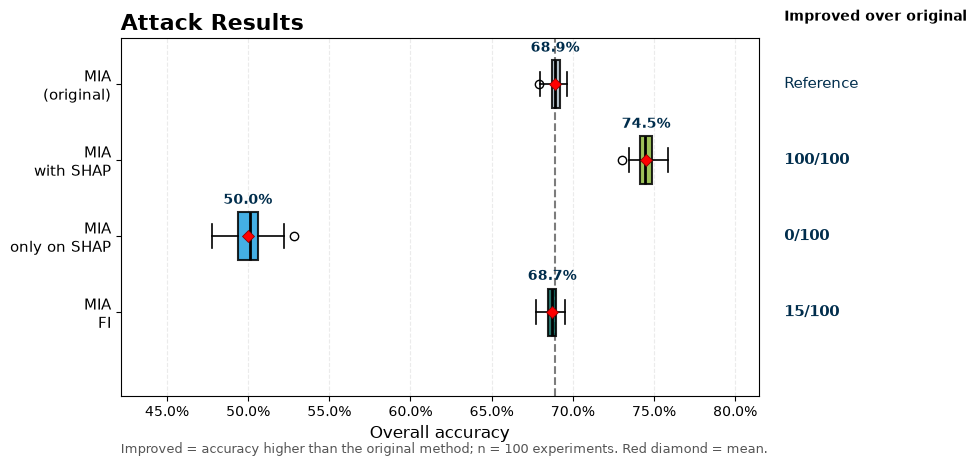

Means per method:
  MIA (original): 0.6892
  MIA with SHAP: 0.7452
  MIA only on SHAP: 0.4999
  MIA FI: 0.6874

Improvement vs original MIA:
  MIA (original): Reference
  MIA with SHAP: 100/100
  MIA only on SHAP: 0/100
  MIA FI: 15/100


In [4]:
# ---- Load data ----
base = Path.cwd().parent / "model_output" / "MIA" 

all_data = []
for i in range(42, 47):
    path = base / f"results_rf_{i}.json"
    if not path.exists():
        print(f"Missing file: {path}")
        continue
    with open(path, "r") as f:
        data = json.load(f)
    for run in data:
        run["_source_file"] = path.name
    all_data.extend(data)

df = pd.DataFrame(all_data)
print(f"Total runs loaded: {len(df)}")

# ---- Extract overall accuracies ----
mia_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia"]["acc"])
mia_on_SHAP_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia_on_SHAP"]["acc"])
mia_with_SHAP_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia_with_SHAP"]["acc"])
mia_FI_acc = df["attacks"].apply(lambda x: x["results_bb_shadow_mia_FI"]["acc"])

data_lists = [
    mia_acc.tolist(),
    mia_with_SHAP_acc.tolist(),
    mia_on_SHAP_acc.tolist(),
    mia_FI_acc.tolist(),
]

methods = [
    "MIA\n(original)",
    "MIA\nwith SHAP",
    "MIA\nonly on SHAP",
    "MIA\nFI"
]

colors = ["#A8B9C4", "#8CB63C", "#23A1E0", "#005A50"]

# Improvement counts vs original MIA, computed run-by-run from real data
n_runs = len(data_lists[0])
improvement_labels = []
for d in data_lists:
    if d is data_lists[0]:
        improvement_labels.append("Reference")
    else:
        count = sum(1 for a, b in zip(d, data_lists[0]) if a > b)
        improvement_labels.append(f"{count}/{n_runs}")

fig, ax = plt.subplots(figsize=(11, 5.5))

# Single source of truth for positions (1-indexed, matches boxplot default)
positions = np.arange(1, len(methods) + 1)

bp = ax.boxplot(
    data_lists,
    vert=False,
    positions=positions,
    patch_artist=True,
    widths=0.62,
    medianprops=dict(color="black", linewidth=2),
    boxprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2)
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

# Mean markers, aligned to the same `positions`
method_means = [np.mean(d) for d in data_lists]
for pos, mean_val in zip(positions, method_means):
    ax.plot(mean_val, pos, "D", color="red", markersize=6, zorder=5,
             markeredgecolor="darkred", markeredgewidth=0.6)

ax.set_yticks(positions)
ax.set_yticklabels(methods, fontsize=11)
ax.invert_yaxis()

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Overall accuracy", fontsize=12)

ax.set_title("Attack Results", loc="left", fontsize=16, fontweight="bold")

ax.grid(axis="x", alpha=0.25, linestyle="--")
ax.set_axisbelow(True)

# Zoomed x-axis range based on actual data spread
all_vals = np.concatenate(data_lists)
data_min, data_max = all_vals.min(), all_vals.max()
padding = (data_max - data_min) * 0.20  # lower this fraction to zoom in further
xmin = max(0.0, data_min - padding)
xmax = min(1.0, data_max + padding)
ax.set_xlim(xmin, xmax)

# Mean value labels above each box
for pos, mean_val in zip(positions, method_means):
    ax.text(
        mean_val, pos - 0.38, f"{mean_val:.1%}",
        ha="center", va="bottom", fontsize=10,
        fontweight="bold", color="#002D4C"
    )

ax.set_yticks(positions)
ax.set_yticklabels(methods, fontsize=11)

# No invert_yaxis() — set ylim directly so "original" (position 1) sits at the top
ax.set_ylim(positions[-1] + 1.1, positions[0] - 0.6)

# Improvement labels on the right, aligned to the same positions
label_color = "#002D4C"
for pos, label in zip(positions, improvement_labels):
    ax.text(
        1.04, pos, label,
        transform=ax.get_yaxis_transform(),
        ha="left", va="center", fontsize=11,
        fontweight="bold" if label != "Reference" else "normal",
        color=label_color, clip_on=False
    )

ax.text(
    1.04, 1.04, "Improved over original",
    transform=ax.transAxes, ha="left", va="bottom",
    fontsize=10, fontweight="bold", clip_on=False
)

# Baseline annotation
baseline_mean = method_means[0]
ax.axvline(baseline_mean, color="#444444", linestyle="--", linewidth=1.5, alpha=0.7, zorder=1)

ax.annotate(
    f"Original baseline: {baseline_mean:.1%}",
    xy=(baseline_mean, positions[0] - 0.75),      # arrow tip, just above the top box
    xytext=(baseline_mean, positions[0] - 1.05),  # text further above, in the new margin
    ha="center", va="bottom", fontsize=10, color="#333333", fontweight="bold",
    arrowprops=dict(arrowstyle="-", color="#444444", linestyle="--", linewidth=1.2)
)

ax.text(
    0.0, -0.16,
    "Improved = accuracy higher than the original method; n = "
    + str(n_runs)
    + " experiments. Red diamond = mean.",
    transform=ax.transAxes, fontsize=9, color="#555555"
)

plt.subplots_adjust(left=0.20, right=0.78, top=0.85, bottom=0.20)
plt.savefig("attack_results_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

print("Means per method:")
for method, mean_val in zip(methods, method_means):
    print(f"  {method.replace(chr(10), ' ')}: {mean_val:.4f}")

print()
print("Improvement vs original MIA:")
for method, label in zip(methods, improvement_labels):
    print(f"  {method.replace(chr(10), ' ')}: {label}")
